# 03 — Simulación Monte Carlo secuencial

## Objetivo

Implementar y validar la simulación Monte Carlo mediante una
estrategia de ejecución secuencial.

Esta implementación servirá como línea base para comparar
posteriormente el rendimiento de una implementación paralela.

## Flujo

Datos procesados
→ parámetros del modelo
→ configuración
→ simulación secuencial
→ resultados

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

PROJECT_ROOT:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo


In [2]:
import numpy as np
import pandas as pd

from src.data.loader import load_csv
from src.simulation.model import NormalReturnModel
from src.simulation.sequential import (
    SimulationConfig,
    SimulationResult,
    simulate_sequential,
)

In [3]:
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró:\n{PROCESSED_DATA_PATH}"
    )

returns_data = load_csv(
    PROCESSED_DATA_PATH
)

print("Datos cargados:")
print(returns_data.shape)

Datos cargados:
(1254, 3)


In [4]:
mean_return = returns_data["log_return"].mean()
volatility = returns_data["log_return"].std()

print(f"Media: {mean_return:.8f}")
print(f"Volatilidad: {volatility:.8f}")

Media: 0.00042932
Volatilidad: 0.01072240


In [5]:
model = NormalReturnModel(
    mean=mean_return,
    volatility=volatility,
)

print(model)

NormalReturnModel(mean=np.float64(0.0004293206341343492), volatility=np.float64(0.010722404490058145))


In [6]:
config = SimulationConfig(
    scenarios=1_000,
    horizon=252,
    initial_value=100.0,
    seed=42,
)

print(config)

SimulationConfig(scenarios=1000, horizon=252, initial_value=100.0, seed=42)


In [7]:
result = simulate_sequential(
    model=model,
    config=config,
)

print(
    "Simulación completada."
)

Simulación completada.


In [8]:
print(
    "Shape de rendimientos:",
    result.returns.shape,
)

print(
    "Shape de precios:",
    result.prices.shape,
)

Shape de rendimientos: (1000, 252)
Shape de precios: (1000, 252)


In [9]:
first_scenario = result.prices[0]

print(
    first_scenario[:10]
)

[100.37034613  99.29994298 100.14518256 101.20370781  99.15109778
  97.81830743  97.99454651  97.70475907  97.72910737  96.88086999]


In [10]:
final_prices = result.prices[:, -1]

print(
    final_prices[:10]
)

[ 97.77417959 118.40167917  86.3287182  113.23739491 106.67614722
 115.53681846  71.83331049  74.92392291 104.9919219  125.4490614 ]


In [11]:
final_returns = (
    final_prices - config.initial_value
) / config.initial_value

print(
    final_returns[:10]
)

[-0.0222582   0.18401679 -0.13671282  0.13237395  0.06676147  0.15536818
 -0.2816669  -0.25076077  0.04991922  0.25449061]


In [12]:
print(
    f"Rendimiento medio: "
    f"{final_returns.mean():.6f}"
)

print(
    f"Rendimiento mínimo: "
    f"{final_returns.min():.6f}"
)

print(
    f"Rendimiento máximo: "
    f"{final_returns.max():.6f}"
)

Rendimiento medio: 0.130619
Rendimiento mínimo: -0.297553
Rendimiento máximo: 0.867135


In [15]:
loss_percentage = (
    final_returns < 0
).mean()

print(
    f"Escenarios con pérdida: "
    f"{loss_percentage:.2%}"
)

Escenarios con pérdida: 25.70%


In [16]:
percentiles = np.percentile(
    final_returns,
    [1, 5, 25, 50, 75, 95, 99],
)

percentiles

array([-0.249615  , -0.15903797, -0.0051059 ,  0.11247042,  0.25064852,
        0.47951328,  0.65746138])

In [17]:
config_same_seed = SimulationConfig(
    scenarios=1000,
    horizon=252,
    initial_value=100.0,
    seed=42,
)

result_same_seed = simulate_sequential(
    model=model,
    config=config_same_seed,
)

In [18]:
same_results = np.array_equal(
    result.prices,
    result_same_seed.prices,
)

print(
    "¿Resultados idénticos?",
    same_results,
)

¿Resultados idénticos? True


In [19]:
config_different_seed = SimulationConfig(
    scenarios=1000,
    horizon=252,
    initial_value=100.0,
    seed=123,
)

result_different_seed = simulate_sequential(
    model=model,
    config=config_different_seed,
)

In [20]:
different_results = np.array_equal(
    result.prices,
    result_different_seed.prices,
)

print(
    "¿Resultados idénticos?",
    different_results,
)

¿Resultados idénticos? False


In [21]:
simulated_returns = result.returns.flatten()

print(
    f"Media histórica/modelo: "
    f"{mean_return:.8f}"
)

print(
    f"Media simulada: "
    f"{simulated_returns.mean():.8f}"
)

print()

print(
    f"Volatilidad histórica/modelo: "
    f"{volatility:.8f}"
)

print(
    f"Volatilidad simulada: "
    f"{simulated_returns.std():.8f}"
)

Media histórica/modelo: 0.00042932
Media simulada: 0.00042951

Volatilidad histórica/modelo: 0.01072240
Volatilidad simulada: 0.01073528


In [22]:
import matplotlib.pyplot as plt

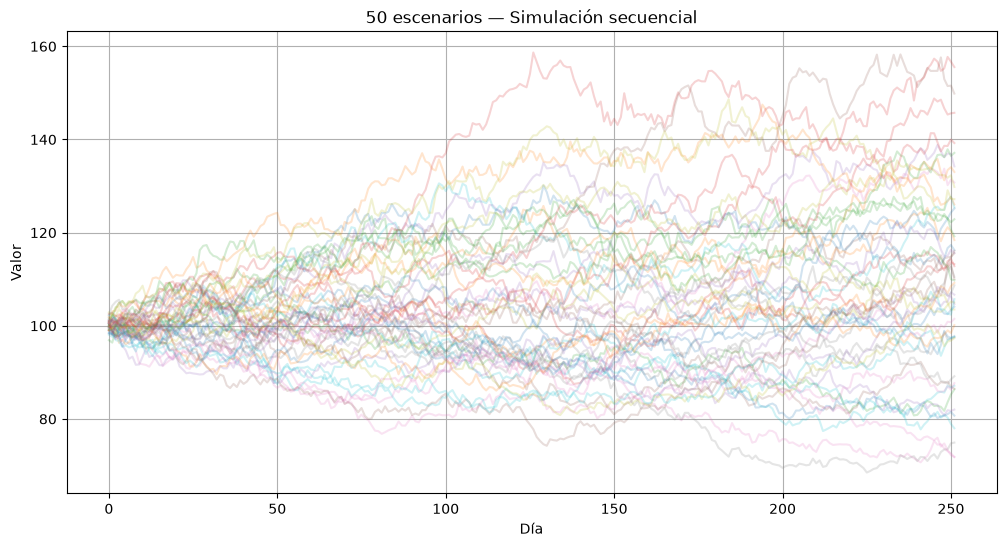

In [24]:
plt.figure(figsize=(12, 6))

for scenario in result.prices[:50]:
    plt.plot(
        scenario,
        alpha=0.2,
    )

plt.title(
    "50 escenarios — Simulación secuencial"
)

plt.xlabel("Día")
plt.ylabel("Valor")

plt.grid(True)

plt.show()

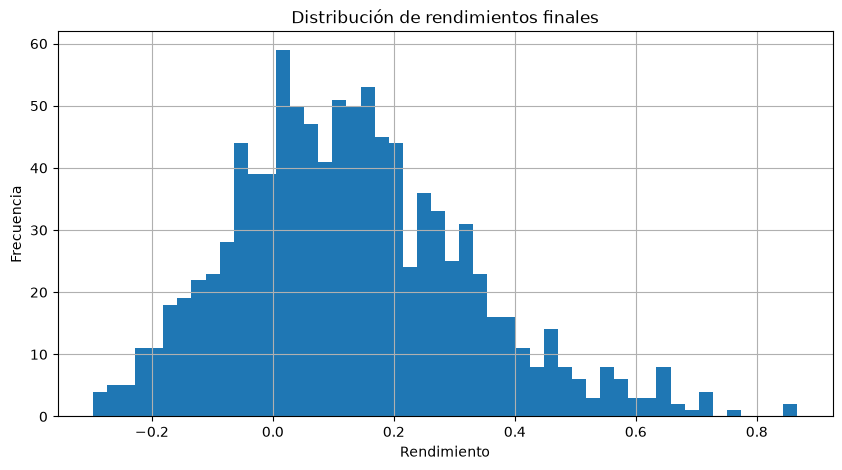

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    final_returns,
    bins=50,
)

plt.title(
    "Distribución de rendimientos finales"
)

plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

In [26]:
small_config = SimulationConfig(
    scenarios=100,
    horizon=252,
    initial_value=100.0,
    seed=42,
)

small_result = simulate_sequential(
    model=model,
    config=small_config,
)

print(
    small_result.prices.shape
)

(100, 252)
